In [160]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("/Users/athipongjindaphram/Documents/ai-job-impact-analysis/ai_job_impact.csv")
df.sample()

,Employee_ID,Age,Gender,Education_Level,Industry,Job_Role,Years_Experience,AI_Adoption_Level,Automation_Risk,Upskilling_Required,Salary_Before_AI,Salary_After_AI,Job_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,Productivity_Change_%
1546,E1547,25,Male,PhD,Education,Professor,0,Low,Medium,Yes,39649,41274,Modified,42,No,6,17.61


In [161]:
risk_data = {
    'Industry': ['IT', 'Healthcare', 'Education', 'Marketing', 'Finance', 'Manufacturing'],
    'Global_Risk_Score': [0.15, 0.25, 0.30, 0.55, 0.70, 0.85]
}
df_risk_score = pd.DataFrame(risk_data)

In [162]:
df_merge = df.copy()
df_merge = df_merge.merge(df_risk_score, how="left", on="Industry")

In [163]:
df_merge = df_merge[(df_merge["Automation_Risk"] == "High") & (df_merge["Global_Risk_Score"] < 0.3)]

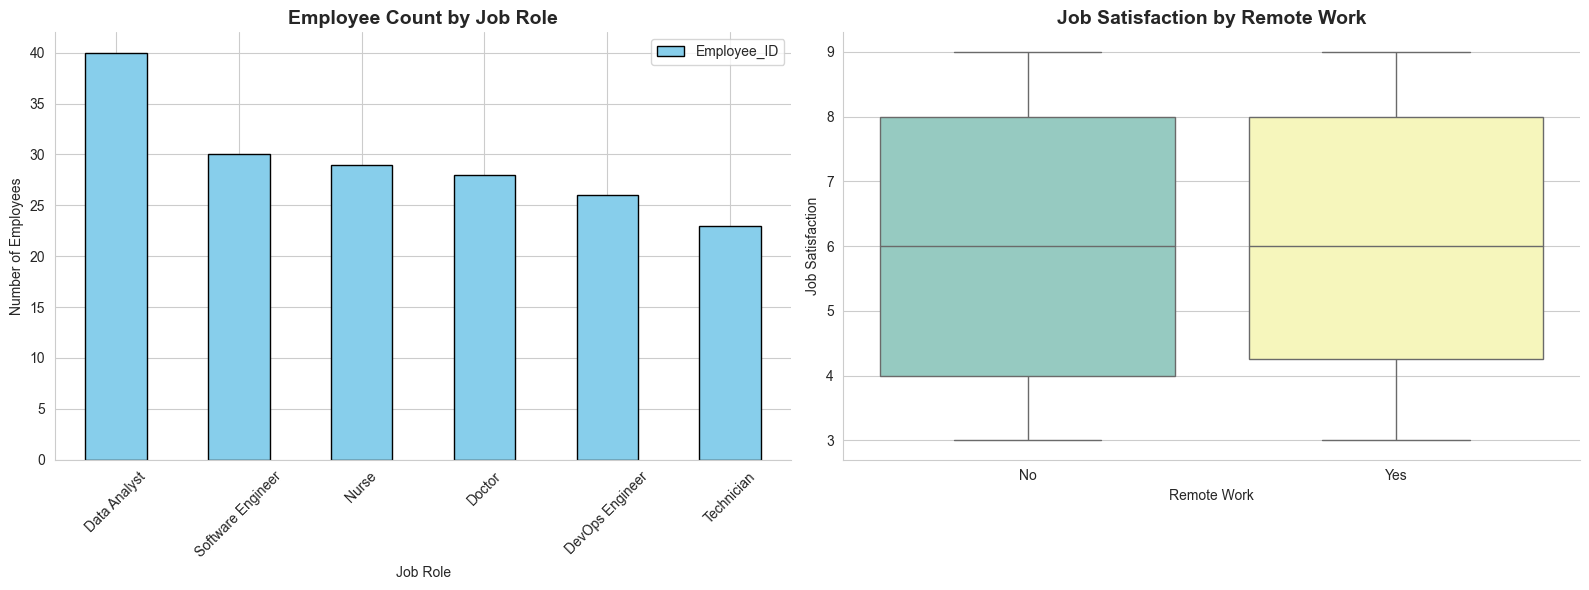

In [164]:
fig, ax = plt.subplots(1,2,figsize=(16,6))

sns.set_style("whitegrid")

df_plot1 = df_merge.groupby("Job_Role")["Employee_ID"].count().sort_values(ascending=False).to_frame()

df_plot1.plot(kind="bar", ax=ax[0], color="skyblue",edgecolor="black")
sns.boxplot(x='Remote_Work', y='Job_Satisfaction', data=df_merge, hue="Remote_Work", palette="Set3", ax=ax[1])

ax[0].set_title(
    "Employee Count by Job Role",
    fontsize=14,
    weight="bold"
)
ax[0].set_xlabel("Job Role")
ax[0].set_ylabel("Number of Employees")
ax[0].tick_params(axis='x', rotation=45)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

ax[1].set_title(
    "Job Satisfaction by Remote Work",
    fontsize=14,
    weight="bold"
)
ax[1].set_xlabel("Remote Work")
ax[1].set_ylabel("Job Satisfaction")
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

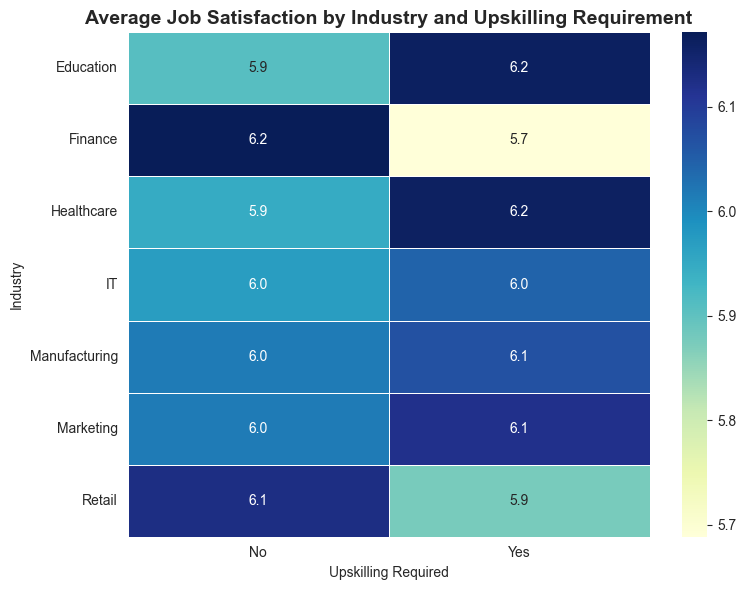

In [165]:
df_pivot = df.pivot_table(
    index="Industry",
    columns="Upskilling_Required",
    values="Job_Satisfaction",
    aggfunc="mean"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    df_pivot,
    annot=True,
    cmap="YlGnBu",
    fmt=".1f",
    linewidths=0.5
)

plt.title(
    "Average Job Satisfaction by Industry and Upskilling Requirement",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Upskilling Required")
plt.ylabel("Industry")

plt.tight_layout()

plt.show()